In [1]:
import sys
sys.path.append("/exp/sbnd/data/users/lnguyen/cafpyana_pi0")
sys.path.append("/exp/sbnd/data/users/lnguyen/cafpyana_pi0/cafpyana")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cafpybara.analyses.nuecc as nue

%load_ext autoreload
%autoreload 2

## load dataframes

In [2]:
dfs_dir = "/exp/sbnd/data/users/lynnt/xsection/samples/MCP2025B_v10_06_00_09/dfs_nu26/"
mcbnb_df, mcbnb_pot, mcbnb_ngen   = nue.load_mc  (dfs_dir+"mc_ar23.df",     keys=['nuecc','hdr'],             cuts=nue.DEFAULT_CUTS)
mclow_df, mclow_pot, mclow_ngen   = nue.load_mc  (dfs_dir+"mc_lowenergy.df",keys=['nuecc','hdr','histpotdf'], cuts=nue.DEFAULT_CUTS)
dtbnb_df, dtbnb_pot, dtbnb_ngates = nue.load_data(dfs_dir+"data_dev.df",    keys=['nuecc','hdr'],onbeam=True, cuts=nue.DEFAULT_CUTS)
dtoff_df, dtoff_pot, dtoff_ngates = nue.load_data(dfs_dir+"offbeamlight.df",keys=['nuecc','hdr'],onbeam=False,cuts=nue.DEFAULT_CUTS)

ongates_per_pot = dtbnb_ngates / dtbnb_pot
f = 0.0725
noffbeamscale_mc = ((1- f)*(ongates_per_pot*mcbnb_pot))/dtoff_ngates
scale = dtbnb_pot/mcbnb_pot

100%|██████████| 1/1 [00:03<00:00,  3.53s/it]


In [3]:
# drop systs that aren't used when using Ar23+
systs_to_drop = ['GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE',
                 'GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE',
                 'GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE',
                 'GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE',
                 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1',
                 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b2',
                 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b3',
                 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b4',
                 ]

for dropcol in systs_to_drop:
    if dropcol in list(zip(*list(mcbnb_df.columns)))[2]:  
        mcbnb_df.drop(dropcol,  axis=1,level=2,inplace=True)

In [4]:
# add the normalization weight columns (used in plotting)
mcbnb_df[('weights_mc', '', '', '', '', '')] =1.0
mclow_df[('weights_mc', '', '', '', '', '')] =mcbnb_pot/mclow_pot
dtoff_df[('weights_mc', '', '', '', '', '')] =noffbeamscale_mc

# flux normalization for systematics 
mcbnb_df[('flux_pot_norm', '', '', '', '', '')] = mcbnb_df.weights_mc/(nue.integrated_flux * (mcbnb_pot / 1e6))
mclow_df[('flux_pot_norm', '', '', '', '', '')] = mclow_df.weights_mc/(nue.integrated_flux * (mcbnb_pot / 1e6))
dtoff_df[('flux_pot_norm', '', '', '', '', '')] = dtoff_df.weights_mc/(nue.integrated_flux * (mcbnb_pot / 1e6))

In [5]:
mcstat_cols = ['__ntuple','entry','rec.slc..index','run','subrun','evt','sample','file_idx']

## selection already applied upon loading
mcmc_df = pd.concat([
                        nue.mcstat(mcbnb_df.assign(sample=0).set_index("sample",append=True).reset_index(),cols=mcstat_cols),
                        nue.mcstat(mclow_df.assign(sample=2).set_index("sample",append=True).reset_index(),cols=mcstat_cols),
                        dtoff_df.assign(sample=3).set_index("sample",append=True).reset_index(),
                       ])
data_df = dtbnb_df.copy()

MCstat universes: 100%|██████████| 2/2 [00:00<00:00, 8933.55it/s]


In [6]:
signal_detvar_file = "/exp/sbnd/data/users/lynnt/xsection/samples/MCP2025B_v10_06_00_09/dfs_nu26/detvars/detvars_signal.h5"
signal_detvar_dict = nue.load_detvar_dict(signal_detvar_file)

# define SystematicsInput to easily pass the common arguments to plotting and systematic extraction
signal_systs_cfg = nue.SystematicsInput(
    mcbnb_pot=mcbnb_pot,
    mcbnb_ngen = mcbnb_ngen,
    detvar_dict=signal_detvar_dict)

# define PlottingConfig for the signal region plots to avoid duplicating arguments 
signal_plots_cfg = nue.PlottingConfig(
    scale=scale,
    ylabel=f"Events [{dtbnb_pot:.2e} POT]",
    systs=signal_systs_cfg,
    percents=True,
    ratio_min=0.,
    ratio_max=2,
    title=" ")

Loaded 14 detvar group(s) from /exp/sbnd/data/users/lynnt/xsection/samples/MCP2025B_v10_06_00_09/dfs_nu26/detvars/detvars_signal.h5  [preprocess: none]
  Keys: ['0xsce_0', '2xsce_0', 'pmtgainfluct_0', 'pmthighnoise_0', 'pmtloweff_0', 'wiremodxw_1', 'wiremodyz_1', 'calo_Ccal', 'calo_alpha', 'calo_beta90', 'calo_R', 'calo_phi', 'calo_yz', 'calo_Ecorr']
  Column check: OK (all DV/CV column sets match)


## make plots

Running through multisims: 100%|██████████| 38/38 [00:00<00:00, 277.17it/s]
14it [00:00, 92.51it/s]
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: overflow encountered in scalar power
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: invalid value encountered in multiply
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/home/lnguyen/.conda/envs/venv_eaf/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:95: RuntimeWarning: invalid value encountered in add
  return sum((e["cov"] for e in syst_dict.values()),


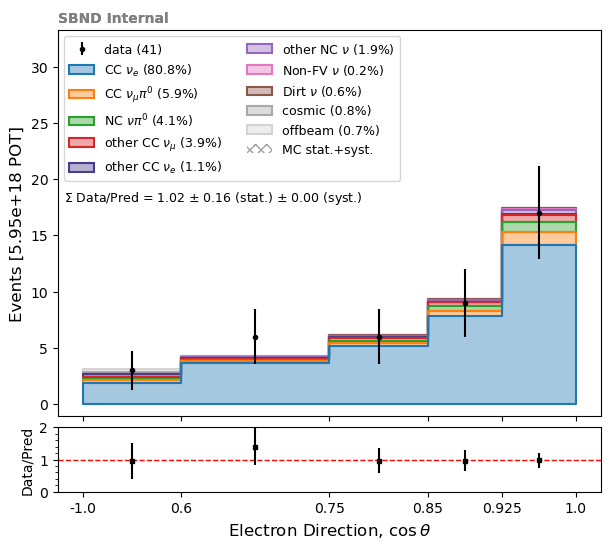

Running through multisims: 100%|██████████| 38/38 [00:00<00:00, 302.96it/s]
14it [00:00, 94.48it/s]
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: overflow encountered in scalar power
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: invalid value encountered in multiply
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/home/lnguyen/.conda/envs/venv_eaf/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:95: RuntimeWarning: invalid value encountered in add
  return sum((e["cov"] for e in syst_dict.values()),


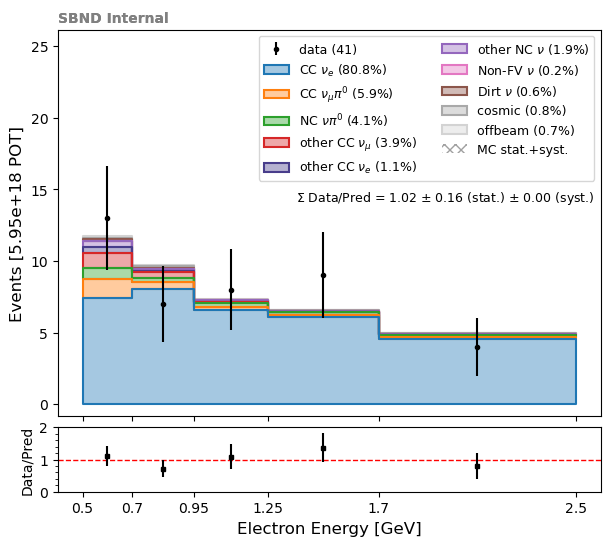

In [7]:
output = nue.plot_mc_data(
                 mc_df   = mcmc_df,
                 data_df = data_df,
                 var=nue.electron_direction().var_evt_reco_col,
                 bins=nue.electron_direction().bins,
                 bin_labels=nue.electron_direction().bin_labels,
                 xlabel="Electron Direction, $\\cos\\theta$",
                 legend_kwargs={'loc':'upper left','ncol':2,'fontsize':9},
                 config=signal_plots_cfg)
plt.show()

output = nue.plot_mc_data(
                 mc_df=mcmc_df,
                 data_df = data_df,
                 var=nue.electron_energy().var_evt_reco_col,
                 bins=nue.electron_energy().bins,
                 bin_labels=nue.electron_energy().bin_labels,
                 xlabel="Electron Energy [GeV]",
                 legend_kwargs={'loc':'upper right','ncol':2,'fontsize':9},
                 config=signal_plots_cfg)
plt.show()

## get syst breakdown

In [8]:
# get the SystematicsOuput explicitly to plot the systs breakdown

signal_energy_output = nue.get_total_cov(
    mcmc_df,
    reco_var=nue.electron_energy().var_evt_reco_col,
    bins=nue.electron_energy().bins,
    **signal_systs_cfg.to_kwargs()
    )
signal_direct_output = nue.get_total_cov(
    mcmc_df,
    reco_var=nue.electron_direction().var_evt_reco_col,
    bins=nue.electron_direction().bins,
    **signal_systs_cfg.to_kwargs()
    )

Running through multisims: 100%|██████████| 38/38 [00:00<00:00, 310.75it/s]
14it [00:00, 90.23it/s]
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: overflow encountered in scalar power
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:110: RuntimeWarning: invalid value encountered in multiply
  syst_dict = {k: {**v, 'cov': v['cov'] * mcbnb_pot ** 2} for k, v in raw_dict.items()}
/home/lnguyen/.conda/envs/venv_eaf/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/exp/sbnd/data/users/lynnt/xsection/nueana/funcs.py:95: RuntimeWarning: invalid value encountered in add
  return sum((e["cov"] for e in syst_dict.values()),
Running through multisims: 100%|██████████| 38/38 [00:00<00:00, 295.52it/s]
14it [00:00, 102.03it/s]
/exp/sbnd/data/users/lynnt/xsection/nu

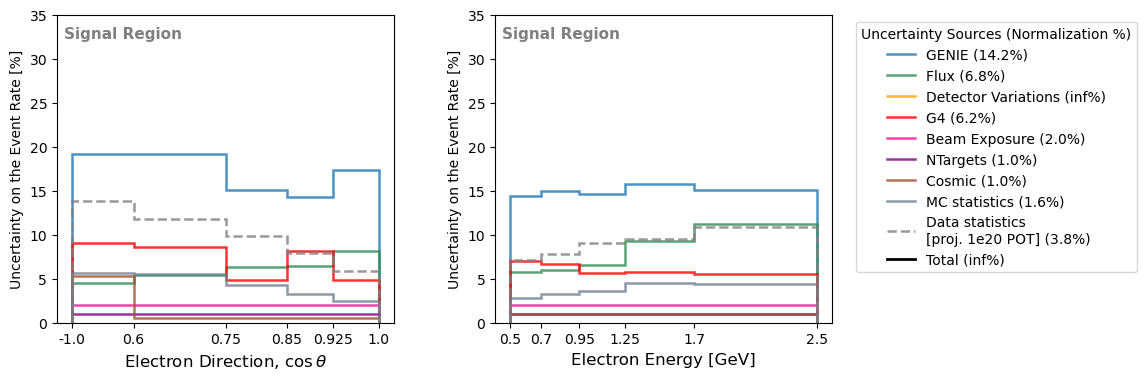

In [9]:
# Syst vars tuple: (SystematicsOutput, bins, xlabel, bin_labels)
_dir_var = nue.electron_direction()
_ene_var = nue.electron_energy()
syst_vars = [
    (signal_direct_output, _dir_var.bins, r"Electron Direction, $\cos\theta$", _dir_var.bin_labels),
    (signal_energy_output,  _ene_var.bins,  "Electron Energy [GeV]",              _ene_var.bin_labels),
]

fig, axes, cats, cat_sums = nue.plot_syst_category_breakdown(
    syst_vars=syst_vars,
    category_dict=nue.category_dict_signal,
)
# plt.savefig(f"{signal_fig_dir}signal_syst_category_breakdown.pdf", bbox_inches='tight')
plt.show()

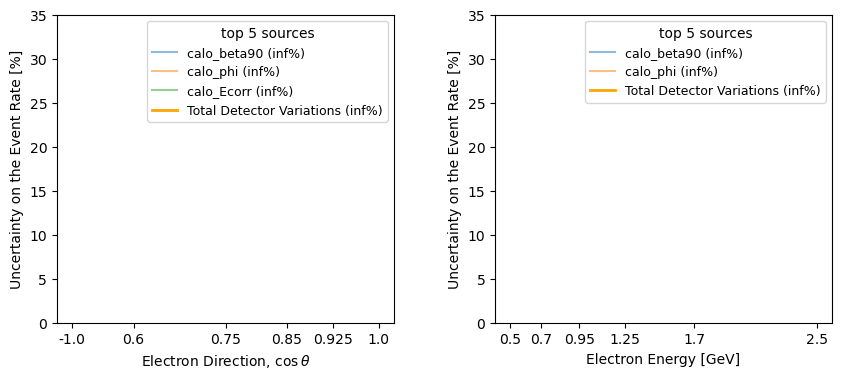

In [10]:
fig, axes = nue.plot_syst_breakdown(
    syst_vars=syst_vars,
    category='DetVar',
    category_dict=nue.category_dict_signal,
)
plt.show()

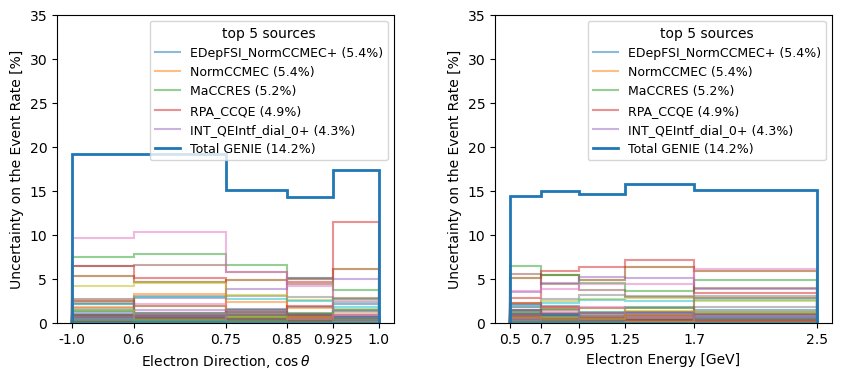

In [11]:
fig, axes = nue.plot_syst_breakdown(
    syst_vars=syst_vars,
    category='GENIE',
    category_dict=nue.category_dict_signal,
)
plt.show()